# 线性回归

In [3]:
%matplotlib inline
import random
import torch



In [5]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
features[:5], labels[:5]

(tensor([[ 1.1398,  0.0835],
         [-1.1503, -0.0695],
         [ 1.3470, -1.1120],
         [ 0.4215, -0.1207],
         [ 0.3174, -0.6184]]),
 tensor([[ 6.1884],
         [ 2.1520],
         [10.6768],
         [ 5.4568],
         [ 6.9262]]))

In [6]:
print('features:', features[:5], '\nlabel:', labels[:5])

features: tensor([[ 1.1398,  0.0835],
        [-1.1503, -0.0695],
        [ 1.3470, -1.1120],
        [ 0.4215, -0.1207],
        [ 0.3174, -0.6184]]) 
label: tensor([[ 6.1884],
        [ 2.1520],
        [10.6768],
        [ 5.4568],
        [ 6.9262]])


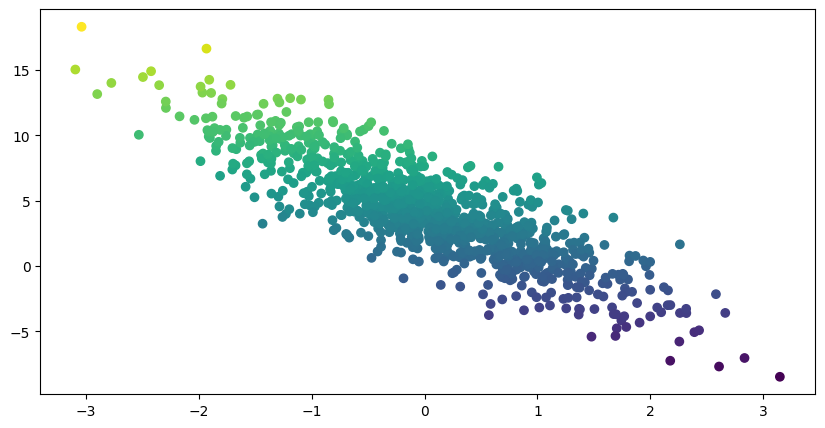

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), c=labels.detach().numpy())
#plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), )

In [11]:
def data_iter(batch_size, features, labels):
    num_examples=len(features)
    indices =list(range(num_examples))
    random.shuffle(indices)  # 样本的读取顺序是随机的
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

for X,y in data_iter(10, features, labels):
    print(X, '\n', y)
    

tensor([[-1.8765,  0.5619],
        [-0.0410,  1.3806],
        [-0.6313, -0.6047],
        [-0.1912,  2.0608],
        [ 0.1397,  0.9637],
        [ 1.0784, -0.8012],
        [ 0.5497, -0.4674],
        [-0.1631, -1.8765],
        [-0.2991,  0.4126],
        [ 0.8606,  0.1206]]) 
 tensor([[-1.4520],
        [-0.5771],
        [ 4.9908],
        [-3.1829],
        [ 1.2101],
        [ 9.0919],
        [ 6.8932],
        [10.2593],
        [ 2.1971],
        [ 5.5263]])
tensor([[-1.4837, -0.1564],
        [ 1.0222, -0.3725],
        [ 1.5476,  0.3163],
        [ 0.9933,  0.1667],
        [-0.9924,  3.1481],
        [-0.4180, -0.5937],
        [-0.4545, -2.9017],
        [-0.2566, -0.7063],
        [-0.4427, -0.6882],
        [-0.1007,  0.8552]]) 
 tensor([[ 1.7703],
        [ 7.5212],
        [ 6.2285],
        [ 5.6280],
        [-8.4797],
        [ 5.3843],
        [13.1529],
        [ 6.0960],
        [ 5.6444],
        [ 1.0921]])
tensor([[-0.0084,  0.4964],
        [ 1.4967, -0.155

In [ ]:
w=torch.normal(0, 0.01, size=(2,1), requires_grad=True)#参数初始化，权重给定是均值为0，标准差为0.01的正态分布随机数，偏置初始化为0
b=torch.zeros(1, requires_grad=True)

In [13]:
def linear_regression(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [14]:
def square_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2 #y_hat和y的形状不一定相同

In [16]:
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size#由于计算方差的时候没有除以样本数，所以这里需要除以batch_size
            param.grad.zero_()

In [17]:
lr=0.03
num_epochs=3
net=linear_regression
loss=square_loss

for epoch in range(num_epochs):
    for X,y in data_iter(10, features, labels):
        l=loss(net(X,w,b),y)
        l.sum().backward()
        sgd([w,b],lr,10)
    with torch.no_grad():
        train_l=loss(net(features,w,b),labels)
        print(f'epoch {epoch+1}, loss {float(train_l.mean()):f}')
        

epoch 1, loss 0.043908
epoch 2, loss 0.000193
epoch 3, loss 0.000050


In [18]:
print(f"w的估计误差: {true_w - w.reshape(true_w.shape)}")
print(f"b的估计误差: {true_b - b}")

w的估计误差: tensor([4.8518e-04, 1.6928e-05], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0002], grad_fn=<RsubBackward1>)
